# Model complexity — variables & interactions

Builds the **hybrid** and **alex** BQMs for every instance stored in the
Gurobi results JSON and records:

- `num_variables` — number of binary decision variables in the QUBO
- `num_interactions` — number of quadratic (off-diagonal) terms

Results are averaged over seeds and shown as `(n, k)` heatmaps, one column
per edge-probability `p`.

In [2]:
import glob
import json
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

# Make sure the repo root is on the path
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from SteinerTreeProblemQUBO.SteinerTree import SteinerTree
from SteinerTreeProblemQUBO.MyFormulization.steiner_to_bqm_hybrid import steiner_to_bqm_hybrid
from SteinerTreeProblemQUBO.AlexFowler.steiner_to_bqm_alex import steiner_to_bqm_ordering

In [3]:
# ── File selection ───────────────────────────────────────────────────────────
# Set GUROBI_JSON_PATH to an explicit path to override auto-detection.
# Set GEO = True to load the geometric benchmark results instead.
GUROBI_JSON_PATH = "/Users/daghanerdonmez/Desktop/evvifing/boun/cmpe/491-492/finale/SteinerTreeProblemQUBO/benchmark/logs/gurobi_new_models_geo_results/new_models_geo_gurobi_20260509_005805.json"
GEO = True   # True -> gurobi_new_models_geo_results / new_models_geo_gurobi_*.json

LOGS_BASE = os.path.join(
    os.path.dirname(os.path.abspath("__file__")),
    "..", "benchmark", "logs",
)

# Constraint weight only affects coefficients, not variable/interaction counts.
CONSTRAINT_WEIGHT = 1.0

def load_gurobi(path=None, geo=False, logs_base=LOGS_BASE):
    if path is None:
        if geo:
            directory = os.path.join(logs_base, "gurobi_new_models_geo_results")
            pattern   = "new_models_geo_gurobi_*.json"
        else:
            directory = os.path.join(logs_base, "gurobi_new_models_results")
            pattern   = "new_models_gurobi_*.json"
        files = sorted(glob.glob(os.path.join(directory, pattern)))
        if not files:
            raise FileNotFoundError(f"No {pattern} found in {directory}.")
        path = files[-1]
    with open(path) as f:
        return json.load(f), path

gurobi_data, gurobi_path = load_gurobi(GUROBI_JSON_PATH, geo=GEO)
meta      = gurobi_data["_meta"]
instances = gurobi_data["instances"]

# ── Detect density axis (sparsity vs geometric) ──────────────────────────────
if "edge_probability_list" in meta:
    density_list  = meta["edge_probability_list"]
    density_label = "p"
    density_key   = "edge_probability"
elif "k_neighbors_list" in meta:
    density_list  = meta["k_neighbors_list"]
    density_label = "knn"
    density_key   = "k_neighbors"
else:
    raise ValueError("Cannot determine density axis from meta keys.")

n_list = meta["node_count_list"]
k_list = meta["terminal_count_list"]

print(f"Loaded       : {gurobi_path}")
print(f"Density axis : {density_label} = {density_list}")
print(f"n            : {n_list}")
print(f"k            : {k_list}")
print(f"Instances    : {len(instances)}")

Loaded       : /Users/daghanerdonmez/Desktop/evvifing/boun/cmpe/491-492/finale/SteinerTreeProblemQUBO/benchmark/logs/gurobi_new_models_geo_results/new_models_geo_gurobi_20260509_005805.json
Density axis : knn = [3, 5, 8]
n            : [4, 6, 8, 10, 12]
k            : [2, 3, 4, 5, 6]
Instances    : 690


In [4]:
# ── Build BQMs and count for every instance ──────────────────────────────────
models = {
    "hybrid": lambda prob: steiner_to_bqm_hybrid(prob, CONSTRAINT_WEIGHT),
    "alex"  : lambda prob: steiner_to_bqm_ordering(prob, CONSTRAINT_WEIGHT),
}

shape = (len(models), len(density_list), len(k_list), len(n_list))
_var_sum  = np.zeros(shape)
_int_sum  = np.zeros(shape)
_cnt      = np.zeros(shape, dtype=int)

model_list = list(models.keys())
total = len(instances)

for idx, (key, inst) in enumerate(instances.items()):
    d_val = inst.get(density_key)
    n_    = inst["node_count"]
    k_    = inst["terminal_count"]
    if d_val not in density_list or n_ not in n_list or k_ not in k_list:
        continue
    di = density_list.index(d_val)
    ni = n_list.index(n_)
    ki = k_list.index(k_)

    # Reconstruct SteinerTree from stored edges/terminals
    nodes   = [f"v{i}" for i in range(inst["num_nodes"])]
    edges   = [tuple(e) for e in inst["edges"]]   # JSON lists → tuples
    problem = SteinerTree(nodes, edges, inst["terminals"])

    for mi, (model_name, build_fn) in enumerate(models.items()):
        bqm = build_fn(problem)
        _var_sum[mi, di, ki, ni] += bqm.num_variables
        _int_sum[mi, di, ki, ni] += bqm.num_interactions
        _cnt    [mi, di, ki, ni] += 1

    if (idx + 1) % 100 == 0 or (idx + 1) == total:
        print(f"  {idx + 1}/{total}", end="\r")

print(f"\nDone. {total} instances processed.")

def _safe_div(num, den):
    out = np.full(num.shape, np.nan)
    mask = den > 0
    out[mask] = num[mask] / den[mask]
    return out

arr_vars = _safe_div(_var_sum, _cnt)
arr_ints = _safe_div(_int_sum, _cnt)

# Mask structurally invalid cells (k > n)
for ki, k in enumerate(k_list):
    for ni, n in enumerate(n_list):
        if k > n:
            arr_vars[:, :, ki, ni] = np.nan
            arr_ints[:, :, ki, ni] = np.nan

print("\nMean variables per model:")
for mi, m in enumerate(model_list):
    finite = arr_vars[mi][np.isfinite(arr_vars[mi])]
    print(f"  {m:6s}: min={finite.min():.0f}  max={finite.max():.0f}  mean={finite.mean():.1f}")

  690/690
Done. 690 instances processed.

Mean variables per model:
  hybrid: min=44  max=671  mean=270.3
  alex  : min=12  max=157  mean=69.0


In [5]:
def plot_complexity(arr, *, title, cbar_label, fmt, cmap,
                    model_list, density_list, density_label, n_list, k_list):
    """
    arr shape: (n_models, n_density, n_k, n_n)
    rows = models, cols = density values
    """
    n_rows, n_cols = len(model_list), len(density_list)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4.5 * n_cols, 4.0 * n_rows),
                             squeeze=False)

    vmin = np.nanmin(arr)
    vmax = np.nanmax(arr)
    mid  = 0.5 * (vmin + vmax)

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color="#dddddd")

    for mi, model in enumerate(model_list):
        for di, d_val in enumerate(density_list):
            ax = axes[mi][di]
            masked = np.ma.masked_invalid(arr[mi, di])
            im = ax.imshow(masked, origin="lower", aspect="auto",
                           cmap=cmap_obj, vmin=vmin, vmax=vmax)
            ax.set_xticks(range(len(n_list)), [str(n) for n in n_list])
            ax.set_yticks(range(len(k_list)), [str(k) for k in k_list])
            ax.set_xlabel("nodes (n)")
            ax.set_ylabel("terminals (k)")
            ax.set_title(f"{model}  |  {density_label} = {d_val}")
            for ki in range(len(k_list)):
                for ni in range(len(n_list)):
                    v = arr[mi, di, ki, ni]
                    if np.isnan(v):
                        ax.text(ni, ki, "—", ha="center", va="center",
                                color="#888", fontsize=8)
                    else:
                        color = "white" if v < mid else "black"
                        ax.text(ni, ki, fmt.format(v), ha="center", va="center",
                                color=color, fontsize=8)
            plt.colorbar(im, ax=ax, label=cbar_label)

    fig.suptitle(title, fontsize=12, y=1.01)
    fig.tight_layout()
    return fig

## Variables

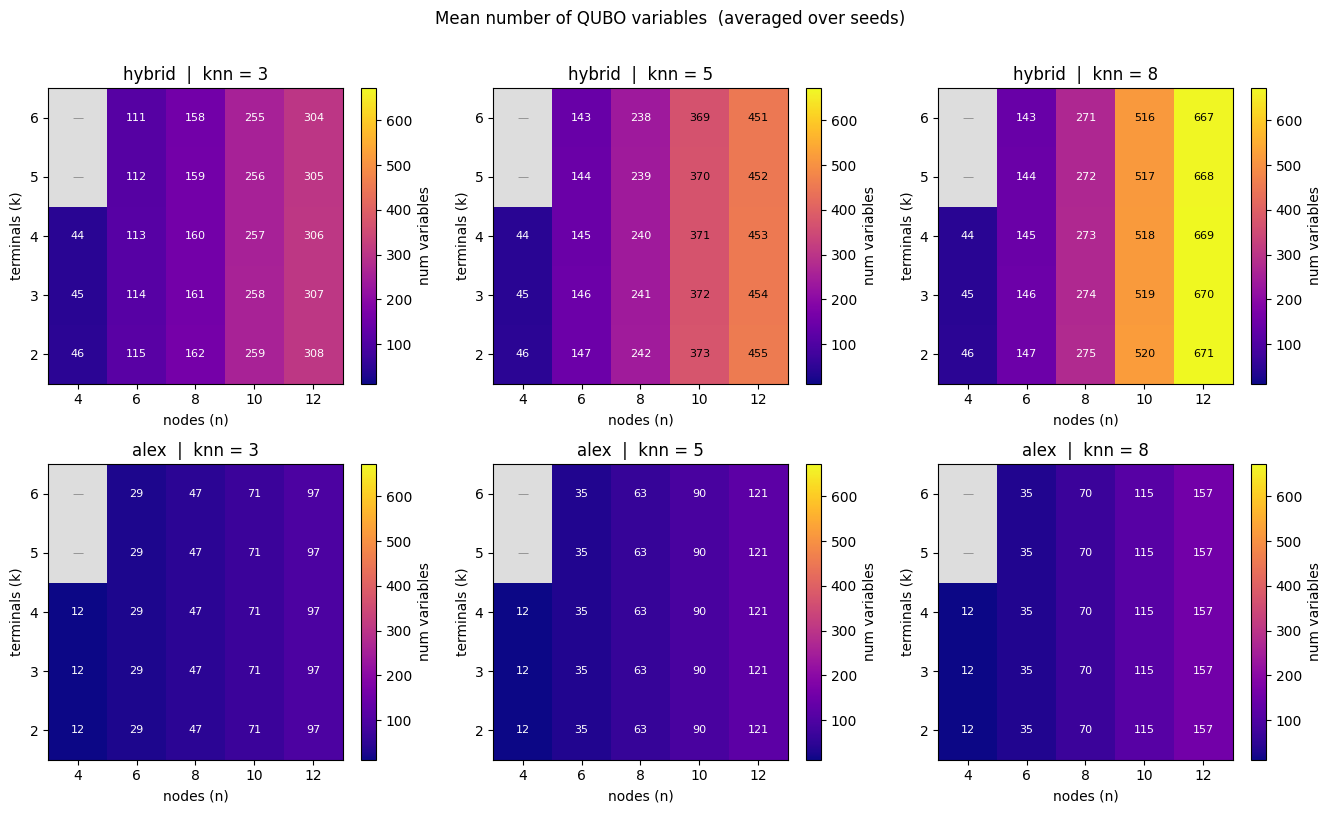

In [6]:
plot_complexity(
    arr_vars,
    title="Mean number of QUBO variables  (averaged over seeds)",
    cbar_label="num variables",
    fmt="{:.0f}",
    cmap="plasma",
    model_list=model_list, density_list=density_list, density_label=density_label,
    n_list=n_list, k_list=k_list,
)
plt.show()

## Interactions (quadratic terms)

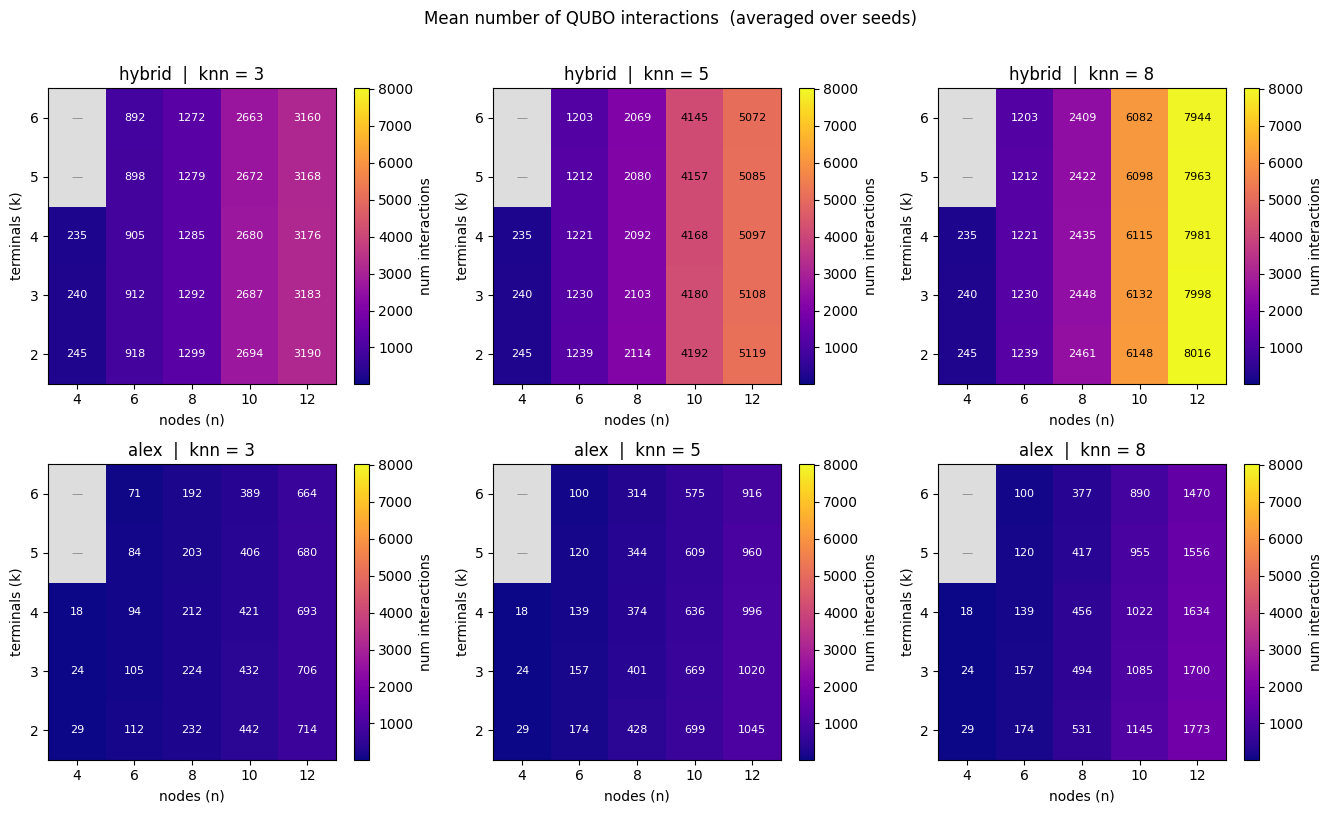

In [7]:
plot_complexity(
    arr_ints,
    title="Mean number of QUBO interactions  (averaged over seeds)",
    cbar_label="num interactions",
    fmt="{:.0f}",
    cmap="plasma",
    model_list=model_list, density_list=density_list, density_label=density_label,
    n_list=n_list, k_list=k_list,
)
plt.show()

## Difference  (hybrid − alex)

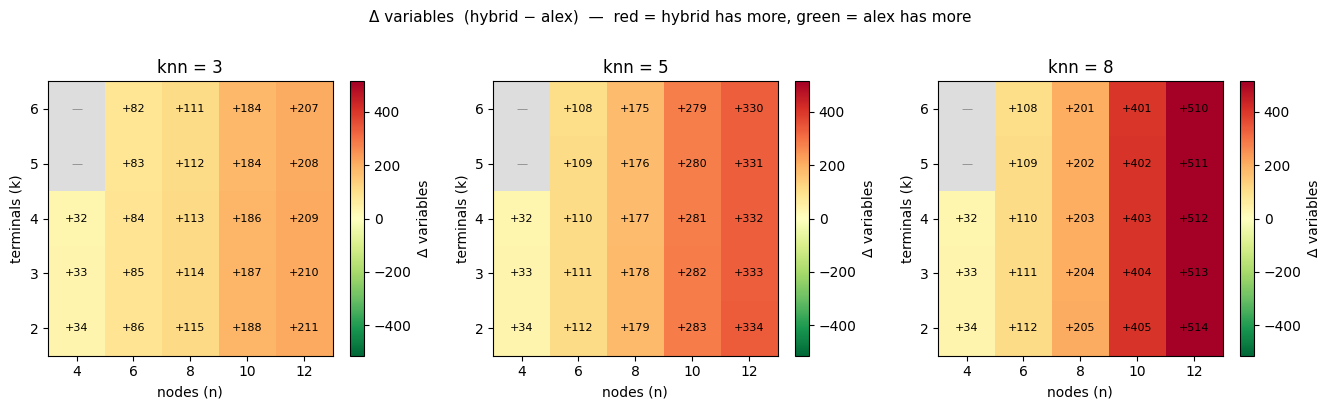

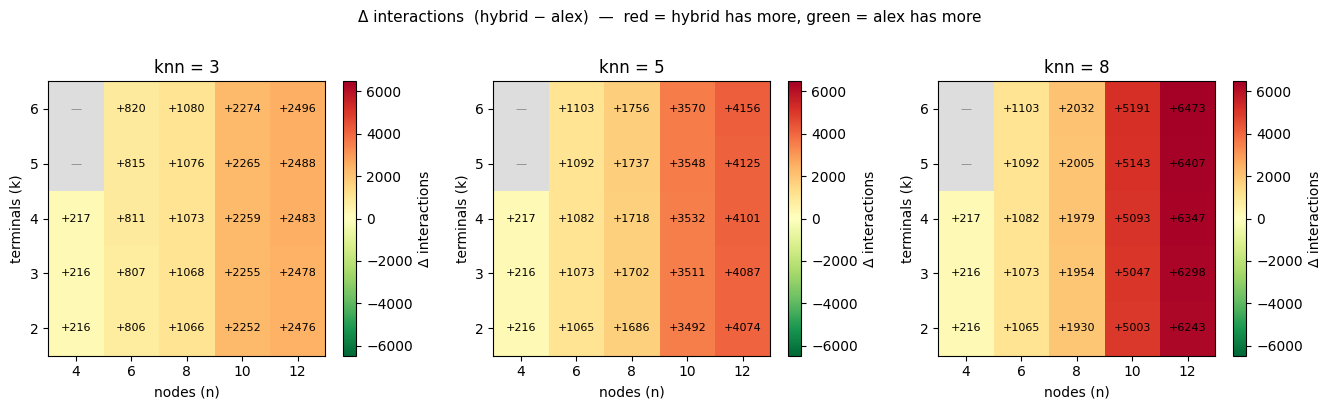

In [8]:
hi = model_list.index("hybrid")
ai = model_list.index("alex")

for arr, label, fmt in [
    (arr_vars, "variables",    "{:+.0f}"),
    (arr_ints, "interactions", "{:+.0f}"),
]:
    diff = arr[hi] - arr[ai]   # shape (density, k, n)
    vext = np.nanmax(np.abs(diff))
    if vext == 0 or np.isnan(vext):
        vext = 1

    fig, axes = plt.subplots(1, len(density_list),
                             figsize=(4.5 * len(density_list), 4.0),
                             squeeze=False)
    cmap_obj = plt.get_cmap("RdYlGn_r").copy()
    cmap_obj.set_bad(color="#dddddd")

    for di, d_val in enumerate(density_list):
        ax = axes[0][di]
        masked = np.ma.masked_invalid(diff[di])
        im = ax.imshow(masked, origin="lower", aspect="auto",
                       cmap=cmap_obj, vmin=-vext, vmax=vext)
        ax.set_xticks(range(len(n_list)), [str(n) for n in n_list])
        ax.set_yticks(range(len(k_list)), [str(k) for k in k_list])
        ax.set_xlabel("nodes (n)")
        ax.set_ylabel("terminals (k)")
        ax.set_title(f"{density_label} = {d_val}")
        for ki in range(len(k_list)):
            for ni in range(len(n_list)):
                v = diff[di, ki, ni]
                if np.isnan(v):
                    ax.text(ni, ki, "—", ha="center", va="center", color="#888", fontsize=8)
                else:
                    ax.text(ni, ki, fmt.format(v), ha="center", va="center",
                            color="black", fontsize=8)
        plt.colorbar(im, ax=ax, label=f"Δ {label}")

    fig.suptitle(
        f"Δ {label}  (hybrid − alex)  —  red = hybrid has more, green = alex has more",
        fontsize=11, y=1.01,
    )
    fig.tight_layout()
    plt.show()